<a href="https://colab.research.google.com/github/tlduongducanh281-jpg/Midterm-Time-Series-/blob/main/midterm_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("data/store_sales/train.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()
print(df.head())


            id  store_nbr      family  sales  onpromotion
date                                                     
2013-01-01   0          1  AUTOMOTIVE    0.0            0
2013-01-01   1          1   BABY CARE    0.0            0
2013-01-01   2          1      BEAUTY    0.0            0
2013-01-01   3          1   BEVERAGES    0.0            0
2013-01-01   4          1       BOOKS    0.0            0


TIME SERIES PLOT


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/store_sales/train.csv")

df["date"] = pd.to_datetime(df["date"])

# Aggregate to 1 time series
daily_sales = df.groupby("date")["sales"].sum().to_frame()

# Set frequency
daily_sales = daily_sales.asfreq("D")

# Fill missing
daily_sales["sales"] = daily_sales["sales"].fillna(method="ffill")

/tmp/ipykernel_155/1523388182.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_sales["sales"] = daily_sales["sales"].fillna(method="ffill")


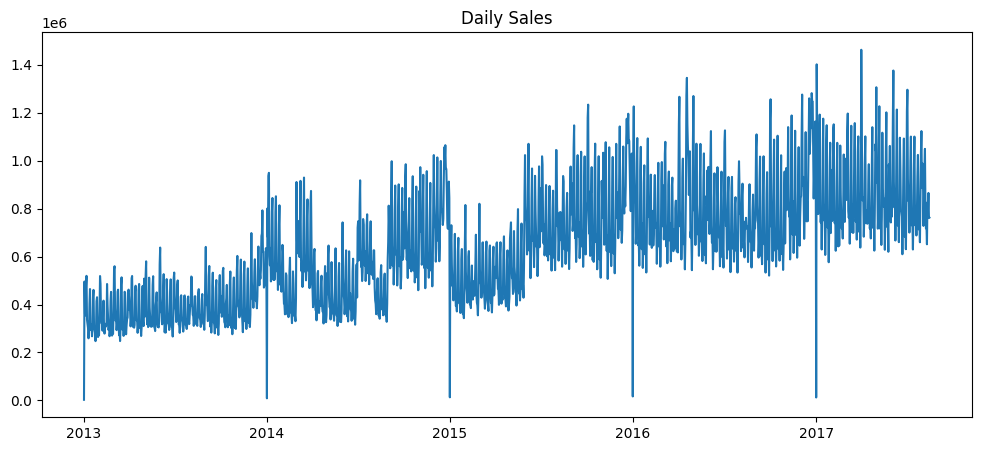

In [3]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["sales"])
plt.title("Daily Sales")
plt.show()

DISTRIBUTION


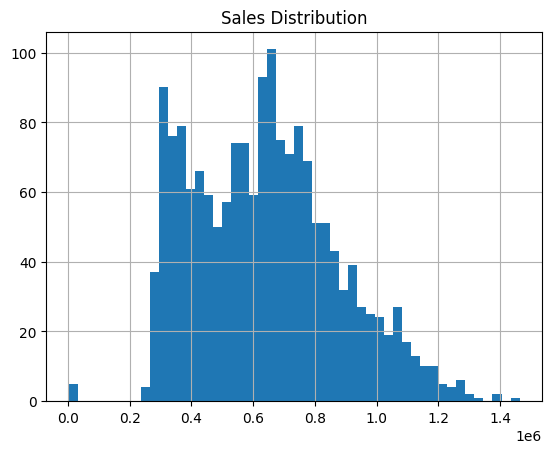

In [4]:
daily_sales["sales"].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

SEASONAL DECOMPOSITION

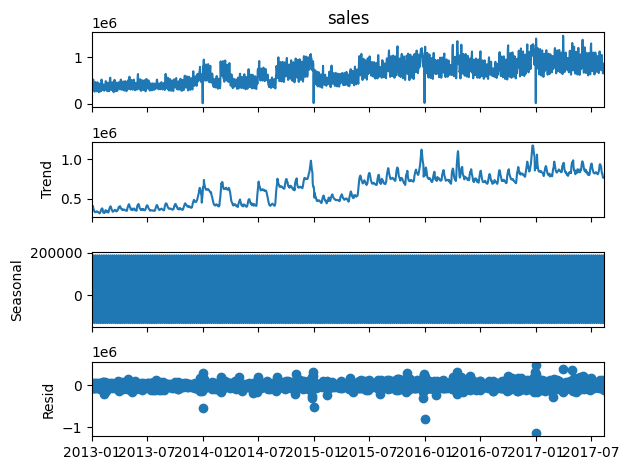

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(daily_sales["sales"], model='additive', period=7)
decomp.plot()
plt.show()

ROLLING STATISTICS

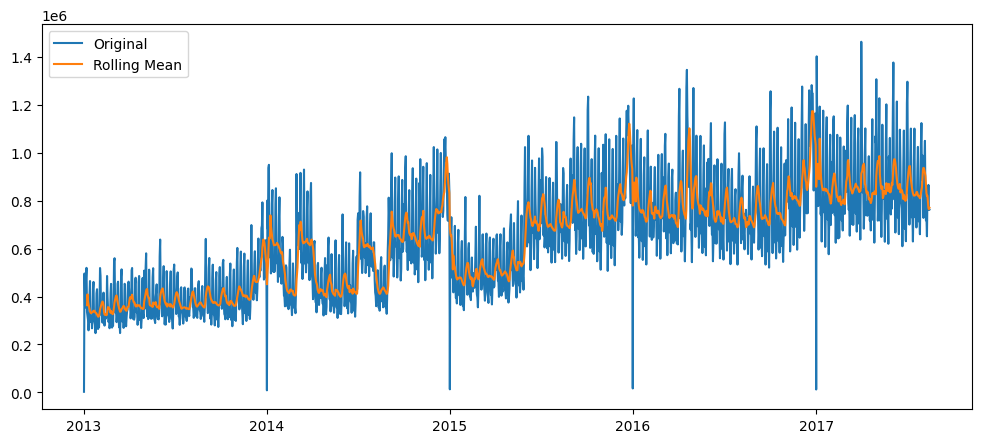

In [6]:
daily_sales["rolling_mean"] = daily_sales["sales"].rolling(7).mean()
daily_sales["rolling_std"] = daily_sales["sales"].rolling(7).std()

plt.figure(figsize=(12,5))
plt.plot(daily_sales["sales"], label="Original")
plt.plot(daily_sales["rolling_mean"], label="Rolling Mean")
plt.legend()
plt.show()

CODE SPLIT (TRAIN / VALID / TEST)


In [7]:
train = daily_sales.iloc[:-60]
valid = daily_sales.iloc[-60:-30]
test = daily_sales.iloc[-30:]

STATIONARITY

In [8]:
from statsmodels.tsa.stattools import adfuller

print("p-value:", adfuller(train["sales"])[1])

p-value: 0.11620209963569306


DIFFERENCING

In [9]:
train_diff = train["sales"].diff().dropna()

ACF/PACF

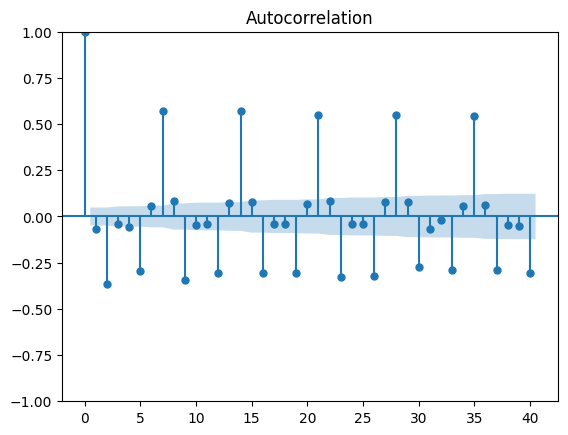

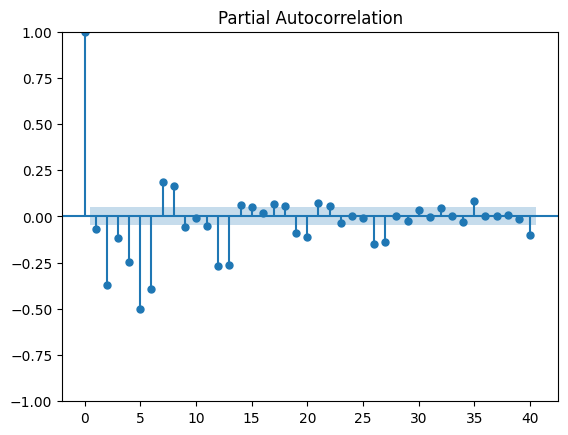

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train_diff, lags=40)
plot_pacf(train_diff, lags=40)
plt.show()

BASELINE MODEL

In [11]:
naive_forecast = test["sales"].shift(1).fillna(method="bfill")

/tmp/ipykernel_155/12638037.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  naive_forecast = test["sales"].shift(1).fillna(method="bfill")


ARIMA MODEL

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["sales"], order=(2,1,2))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


VALIDATION TUNNING

In [13]:
val_forecast = model_fit.forecast(steps=30)

FINAL TRAIN

In [14]:
final_model = ARIMA(daily_sales.iloc[:-30]["sales"], order=(2,1,2)).fit()
forecast = final_model.forecast(steps=30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


EVALUATION

In [15]:
# Naive forecast: dùng giá trị ngày trước đó
naive_forecast = test.shift(1)

# bỏ giá trị NaN đầu tiên
naive_forecast = naive_forecast.dropna()
test_aligned = test[1:]

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true))*100

mae = mean_absolute_error(test["sales"], forecast)
rmse = np.sqrt(mean_squared_error(test["sales"], forecast))
mape_val = mape(test["sales"], forecast)

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)
print("ARIMA MAPE:", mape_val)

ARIMA MAE: 113951.87429744887
ARIMA RMSE: 128839.24203342569
ARIMA MAPE: 14.089418062859016


BASELINE vs ARIMA


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae_naive = mean_absolute_error(test_aligned, naive_forecast)

# RMSE
rmse_naive = np.sqrt(mean_squared_error(test_aligned, naive_forecast))

# MAPE
mape_naive = np.mean(np.abs((test_aligned - naive_forecast) / test_aligned)) * 100

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)
print("Naive MAPE:", mape_naive)

Naive MAE: 43420.825852115806
Naive RMSE: 75295.59505923244
Naive MAPE: 7.54355515244048


VISUAL RESULT


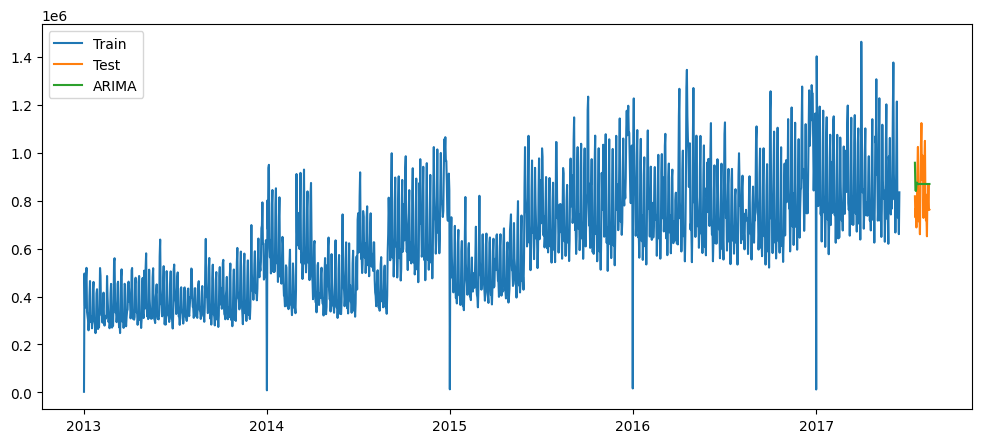

In [18]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train["sales"], label="Train")
plt.plot(test.index, test["sales"], label="Test")
plt.plot(test.index, forecast, label="ARIMA")
plt.legend()
plt.show()

RESIDUAL DIAGNOSTICS

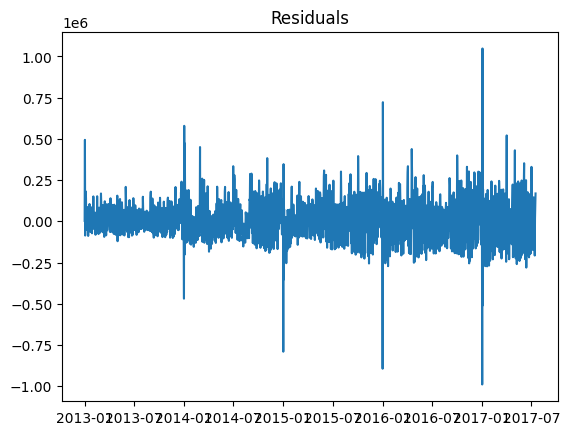

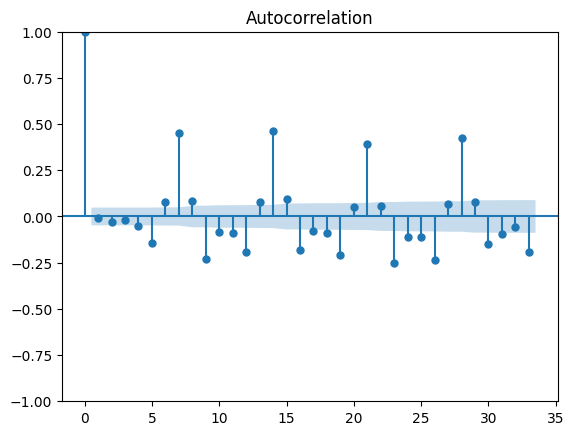

In [19]:
residuals = final_model.resid

plt.plot(residuals)
plt.title("Residuals")
plt.show()

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals)
plt.show()

ML MODEL

In [20]:
# Feature engineering
daily_sales["dayofweek"] = daily_sales.index.dayofweek
daily_sales["month"] = daily_sales.index.month

from sklearn.ensemble import RandomForestRegressor

X = daily_sales[["dayofweek", "month"]]
y = daily_sales["sales"]

X_train = X.iloc[:-30]
X_test = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test = y.iloc[-30:]

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, rf_pred))

RF MAE: 224829.7509936332
